In [92]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib.abstract as ta

In [93]:
# Apple Futures data using yfinance
ticker = 'AAPL'
data = yf.download(ticker, start="2022-01-01")

# Check the data
display(data.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.270309,179.122444,174.058672,174.176201,104487900
2022-01-04,176.007782,179.181217,175.439697,178.877588,99310400
2022-01-05,171.325974,176.468103,171.051728,175.919612,94537600
2022-01-06,168.465988,171.698187,168.113384,169.151603,96904000
2022-01-07,168.632523,170.562047,167.515946,169.337730,86709100


In [94]:
data.columns = ['Close','High','Low','Open','Volume']

In [95]:
# Check the data
display(data.head())

,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,178.270309,179.122444,174.058672,174.176201,104487900
2022-01-04,176.007782,179.181217,175.439697,178.877588,99310400
2022-01-05,171.325974,176.468103,171.051728,175.919612,94537600
2022-01-06,168.465988,171.698187,168.113384,169.151603,96904000
2022-01-07,168.632523,170.562047,167.515946,169.337730,86709100


# Utils

In [96]:
import pandas as pd 
from typing import List, Dict
from itertools import product

In [97]:
def set_position(data:pd.DataFrame) -> pd.DataFrame:
    in_position = False
    # Index yerine satır sayısına göre dönüyoruz (range(1, ...))
    for i in range(1, len(data)):
        # Mevcut ve bir önceki satırı konum (integer) olarak seçiyoruz
        curr_val = data['Position'].iloc[i]
        prev_val = data['Position'].iloc[i-1]
        
        potential_buy = curr_val and not prev_val
        potential_exit = not curr_val and prev_val
        
        if potential_buy and not in_position:
            data.iloc[i, data.columns.get_loc('Signal')] = 1
            in_position = True
        elif potential_exit and in_position:
            data.iloc[i, data.columns.get_loc('Signal')] = -1
            in_position = False
    return data

In [98]:
def calculate_return(data: pd.DataFrame) -> pd.DataFrame:
    # Günlük piyasa getirisi
    data['Market_Return'] = data['Close'].pct_change()
    

    data['Strategy_Return'] = data['Market_Return'] * data['Position'].shift(1)
    
    data['BuyHold_Return'] = data['Market_Return']
    
    
    data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return'].fillna(0)).cumprod()
    data['Cumulative_BuyHold_Return'] = (1 + data['BuyHold_Return'].fillna(0)).cumprod()
    
    # Yüzde olarak (grafikte göstermek için)
    data['Cumulative_Strategy_Pct'] = (data['Cumulative_Strategy_Return'] - 1) * 100
    data['Cumulative_BuyHold_Pct'] = (data['Cumulative_BuyHold_Return'] - 1) * 100
    
    
    # Running maximum
    data['Strategy_Peak'] = data['Cumulative_Strategy_Return'].cummax()
    
    # Drawdown yüzdesi
    data['Strategy_Drawdown'] = (data['Cumulative_Strategy_Return'] - data['Strategy_Peak']) / data['Strategy_Peak'] * 100
    
    
    # 30 günlük rolling volatilite
    data['Rolling_Volatility'] = data['Strategy_Return'].rolling(window=30).std() * np.sqrt(252) * 100
    
    # 30 günlük rolling Sharpe
    rolling_mean = data['Strategy_Return'].rolling(window=30).mean() * 252
    rolling_std = data['Strategy_Return'].rolling(window=30).std() * np.sqrt(252)
    data['Rolling_Sharpe'] = rolling_mean / rolling_std
    
    return data


In [99]:
def calculate_metrics(data: pd.DataFrame) -> dict:
    
    # Toplam getiriler
    total_strategy_return = (data['Cumulative_Strategy_Return'].iloc[-1] - 1) * 100
    total_buyhold_return = (data['Cumulative_BuyHold_Return'].iloc[-1] - 1) * 100
    
    # Yıllık volatilite
    strategy_volatility = data['Strategy_Return'].std() * np.sqrt(252) * 100
    
    # Sharpe Ratio
    strategy_sharpe = (data['Strategy_Return'].mean() * 252) / (data['Strategy_Return'].std() * np.sqrt(252))
    buyhold_sharpe = (data['BuyHold_Return'].mean() * 252) / (data['BuyHold_Return'].std() * np.sqrt(252))
    
    # Maximum Drawdown
    max_drawdown = data['Strategy_Drawdown'].min()
    
    
    trades = []
    entry_price = None
    
    for idx, row in data.iterrows():
        if row['Signal'] == 1:  # Buy
            entry_price = row['Close']
            entry_date = idx
        elif row['Signal'] == -1 and entry_price is not None:  # Sell
            trade_return = (row['Close'] - entry_price) / entry_price * 100
            trades.append({
                'entry': entry_date,
                'exit': idx,
                'return': trade_return
            })
            entry_price = None
    
    trades_df = pd.DataFrame(trades)
    
    # Trade istatistikleri
    trade_count = len(trades_df)
    if trade_count > 0:
        win_rate = (trades_df['return'] > 0).sum() / trade_count * 100
        avg_trade = trades_df['return'].mean()
        avg_win = trades_df[trades_df['return'] > 0]['return'].mean() if (trades_df['return'] > 0).any() else 0
        avg_loss = trades_df[trades_df['return'] <= 0]['return'].mean() if (trades_df['return'] <= 0).any() else 0
    else:
        win_rate = avg_trade = avg_win = avg_loss = 0
    
    return {
        'Strategy_Return': total_strategy_return,
        'BuyHold_Return': total_buyhold_return,
        'Outperformance': total_strategy_return - total_buyhold_return,
        'Strategy_Volatility': strategy_volatility,
        'Strategy_Sharpe': strategy_sharpe,
        'BuyHold_Sharpe': buyhold_sharpe,
        'Max_Drawdown': max_drawdown,
        'Trade_Count': trade_count,
        'Win_Rate': win_rate,
        'Avg_Trade': avg_trade,
        'Avg_Win': avg_win,
        'Avg_Loss': avg_loss
    }

In [100]:
def plot_signals(data: pd.DataFrame, trends: List[str], metrics: dict) -> None:
    # Figür ve Eksen oluşturma (Doğru yöntem)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1]})
    in_position = False
    buy_idx = None
    for i, idx in enumerate(data.index):
        if data.loc[idx, 'Signal'] == 1:  # Buy sinyali
            buy_idx = idx
            in_position = True
        elif data.loc[idx, 'Signal'] == -1 and in_position:  # Sell sinyali
            ax1.axvspan(buy_idx, idx, alpha=0.2, color='green', label='_nolegend_')
            in_position = False
    
    # Eğer son pozisyon hala açıksa (satış yapılmadıysa)
    if in_position and buy_idx is not None:
        ax1.axvspan(buy_idx, data.index[-1], alpha=0.2, color='green', label='_nolegend_')

    # Fiyat ve Hareketli Ortalamaları Çizme
    ax1.plot(data.index, data['Close'], label='Close Price', alpha=0.5, linewidth=1.5, color='gray')
    for trend in trends:
        ax1.plot(data.index, data[trend], label=trend, alpha=0.75)

    # Satın alma sinyalleri (Signal == 1)
    ax1.scatter(data.index[data['Signal'] == 1], 
                data['Close'][data['Signal'] == 1], 
                label='Buy Signal', marker='^', color='green', alpha=1, s=100, zorder=5)

    # Satış/Çıkış sinyalleri (Signal == -1)
    ax1.scatter(data.index[data['Signal'] == -1], 
                data['Close'][data['Signal'] == -1], 
                label='Exit Signal', marker='v', color='red', alpha=1, s=100, zorder=5)

    # Grafik Süslemeleri
    ax1.set_title('Trading Strategies', fontsize=15)
    ax1.set_xlabel('Tarih')
    ax1.set_ylabel('Fiyat')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)


    ax2.plot(data['Cumulative_Strategy_Pct'], label='Strategy Returns (%)', 
             color='steelblue', linewidth=1.5)
    ax2.plot(data['Cumulative_BuyHold_Pct'], label='Buy & Hold Returns (%)', 
             color='orange', linewidth=1.5)
    
    # Metrik kutusu
    stats_text = (
        f"Strategy Sharpe: {metrics['Strategy_Sharpe']:.2f}\n"
        f"Buy & Hold Sharpe: {metrics['BuyHold_Sharpe']:.2f}\n\n"
        f"Trade Count: {metrics['Trade_Count']}\n"
        f"Win Rate: {metrics['Win_Rate']:.2f}%\n"
        f"Avg Trade: {metrics['Avg_Trade']:.2f}%"
    )
    ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax2.set_ylabel('Returns (%)')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

    plt.show()

In [101]:
def backtest(data, trends):
    data = calculate_return(data)
    metrics = calculate_metrics(data)    
    plot_signals(data, trends, metrics)

# Strategies

- Trend Finding Strategy
- Triple MA crossover
- Mean reversion with Z score
- Statistical Arbitrage 
-  RVI Crossover

## Trend Finding Strategy

In [102]:
data_tf = data.copy()

In [103]:
data_tf["Short"] = ta.SMA(data_tf["Close"],50)
data_tf["Long"] = ta.SMA(data_tf["Close"],200)
data_tf['Position'] = (data_tf['Short'] > data_tf['Long'])
data_tf['Signal'] = 0

In [104]:
data_tf = set_position(data_tf)

In [105]:
data_tf.head()

,Close,High,Low,Open,Volume,Short,Long,Position,Signal
Date,,,,,,,,,
2022-01-03,178.270309,179.122444,174.058672,174.176201,104487900,NaN,NaN,False,0
2022-01-04,176.007782,179.181217,175.439697,178.877588,99310400,NaN,NaN,False,0
2022-01-05,171.325974,176.468103,171.051728,175.919612,94537600,NaN,NaN,False,0
2022-01-06,168.465988,171.698187,168.113384,169.151603,96904000,NaN,NaN,False,0
2022-01-07,168.632523,170.562047,167.515946,169.337730,86709100,NaN,NaN,False,0


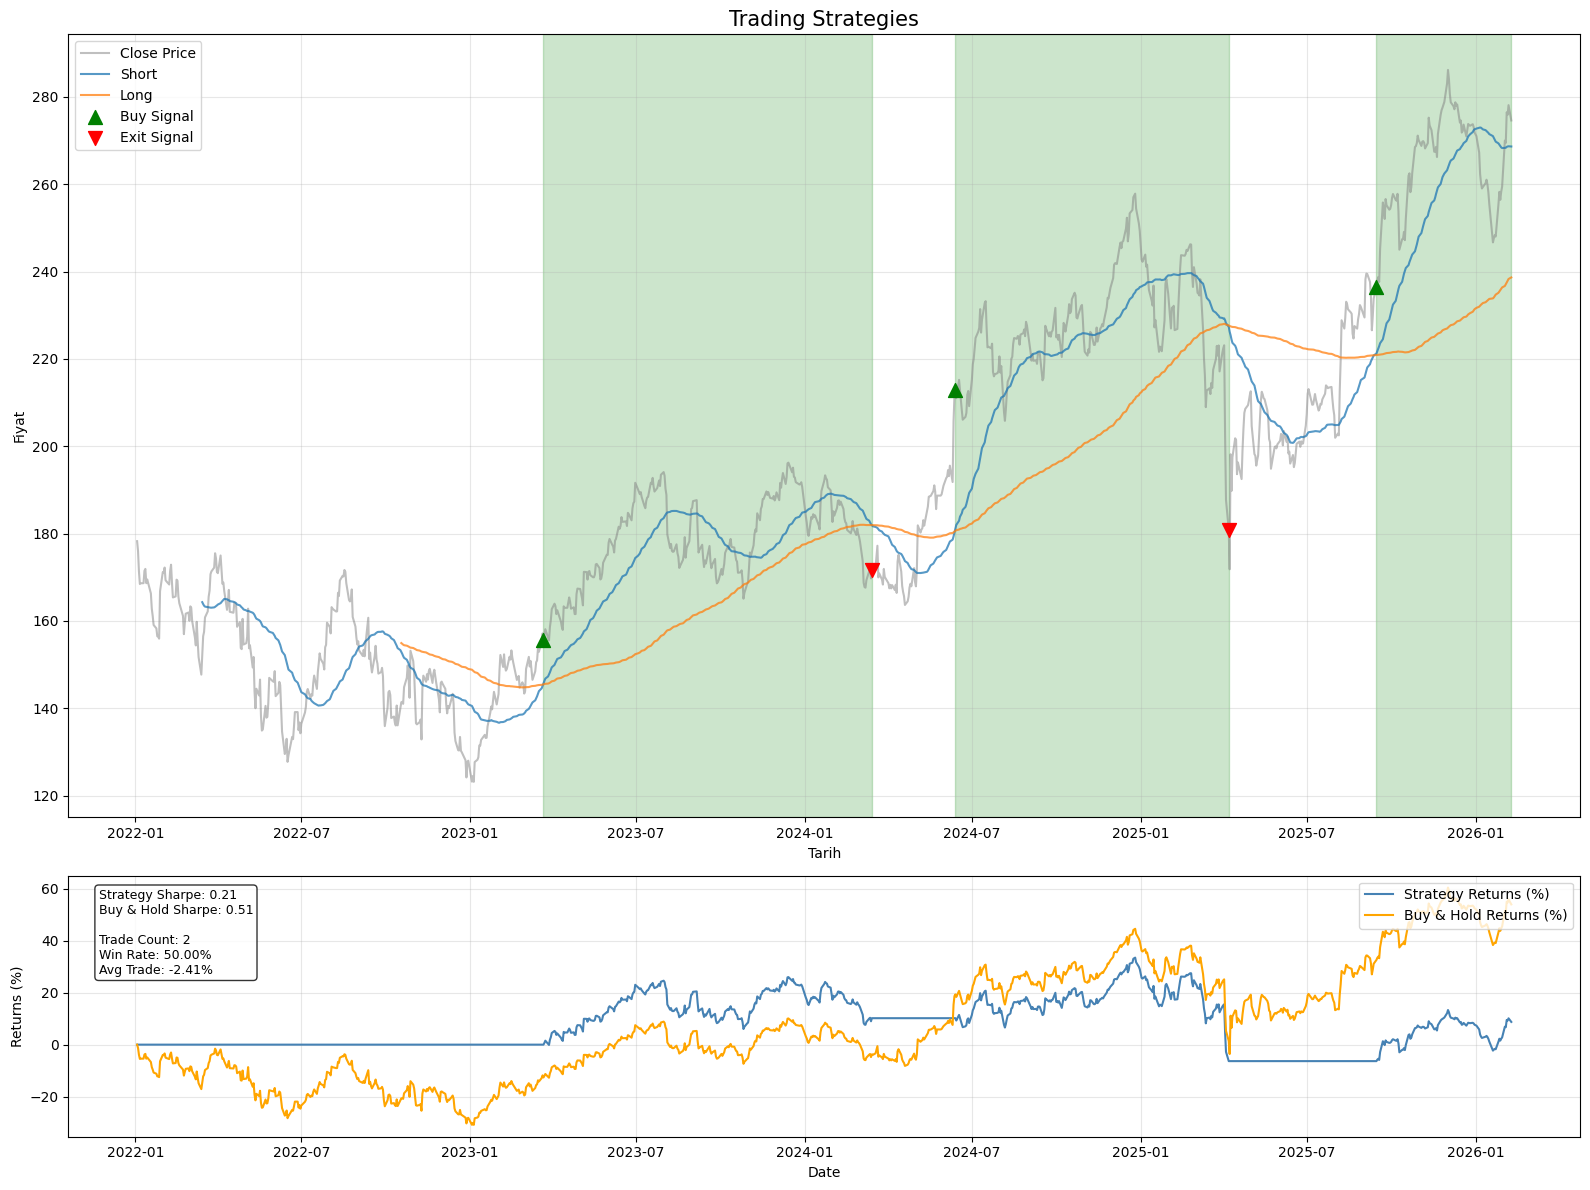

In [106]:
backtest(data_tf, ['Short','Long'])

## Triple Moving Average Crossover 

In [107]:
data_tma = data.copy()

In [108]:
data_tma["Short"]=ta.EMA(data_tma["Close"],20)
data_tma["Long"]=ta.EMA(data_tma["Close"],50)
data_tma["Trend"]=ta.EMA(data_tma["Close"],200)

data_tma['Position'] = (data_tma['Close'] > data_tma['Trend']) & (data_tma['Short'] > data_tma['Long'])
data_tma['Signal'] = 0

In [109]:
data_tma = set_position(data_tma)

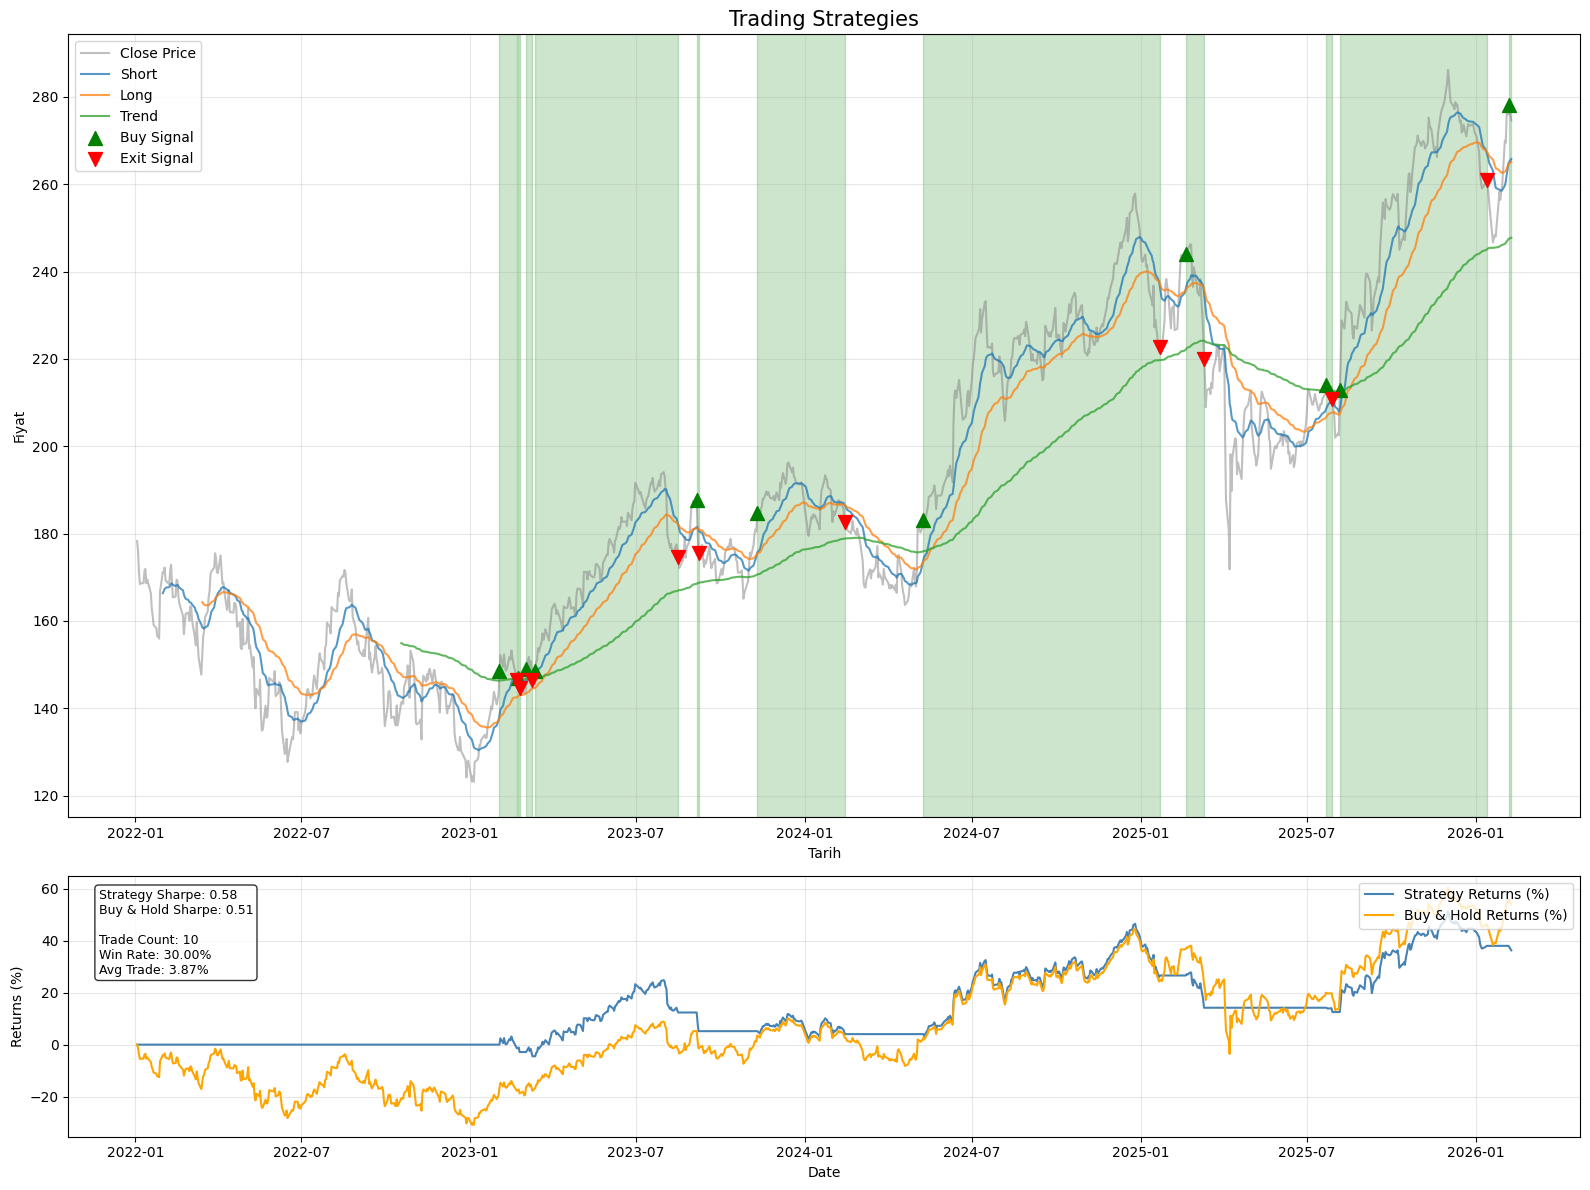

In [110]:
backtest(data_tma, ['Short','Long','Trend'])

## Mean Reversion with Z Score

In [111]:
data_mr = data.copy()

In [112]:
window=20

# Calculate the 50-day moving average
data_mr['Trend'] = data_mr['Close'].rolling(window=window).mean()

# Calculate the standard deviation of the 10-day moving average
data_mr['STD']  = data_mr['Close'].rolling(window=window).std()

# Calculate the z-score (number of standard deviations away from the mean)
data_mr['Z']  = (data_mr['Close'] - data_mr['Trend']) / data_mr['STD']

# Buy order if the z-score is less than n_std (=1)
# Sell order if the z-score is more than n_std (=1)
# Hold if between -1 and 1
n_std=1.25

In [113]:
data_mr['Position'] = np.where(data_mr['Z'] < -n_std, 1, np.where(data_mr['Z'] > n_std,-1, 0))
data_mr['Signal'] = 0

In [114]:
data_mr = set_position(data_mr)

In [115]:
data_mr.head()

,Close,High,Low,Open,Volume,Trend,STD,Z,Position,Signal
Date,,,,,,,,,,
2022-01-03,178.270309,179.122444,174.058672,174.176201,104487900,NaN,NaN,NaN,0,0
2022-01-04,176.007782,179.181217,175.439697,178.877588,99310400,NaN,NaN,NaN,0,0
2022-01-05,171.325974,176.468103,171.051728,175.919612,94537600,NaN,NaN,NaN,0,0
2022-01-06,168.465988,171.698187,168.113384,169.151603,96904000,NaN,NaN,NaN,0,0
2022-01-07,168.632523,170.562047,167.515946,169.337730,86709100,NaN,NaN,NaN,0,0


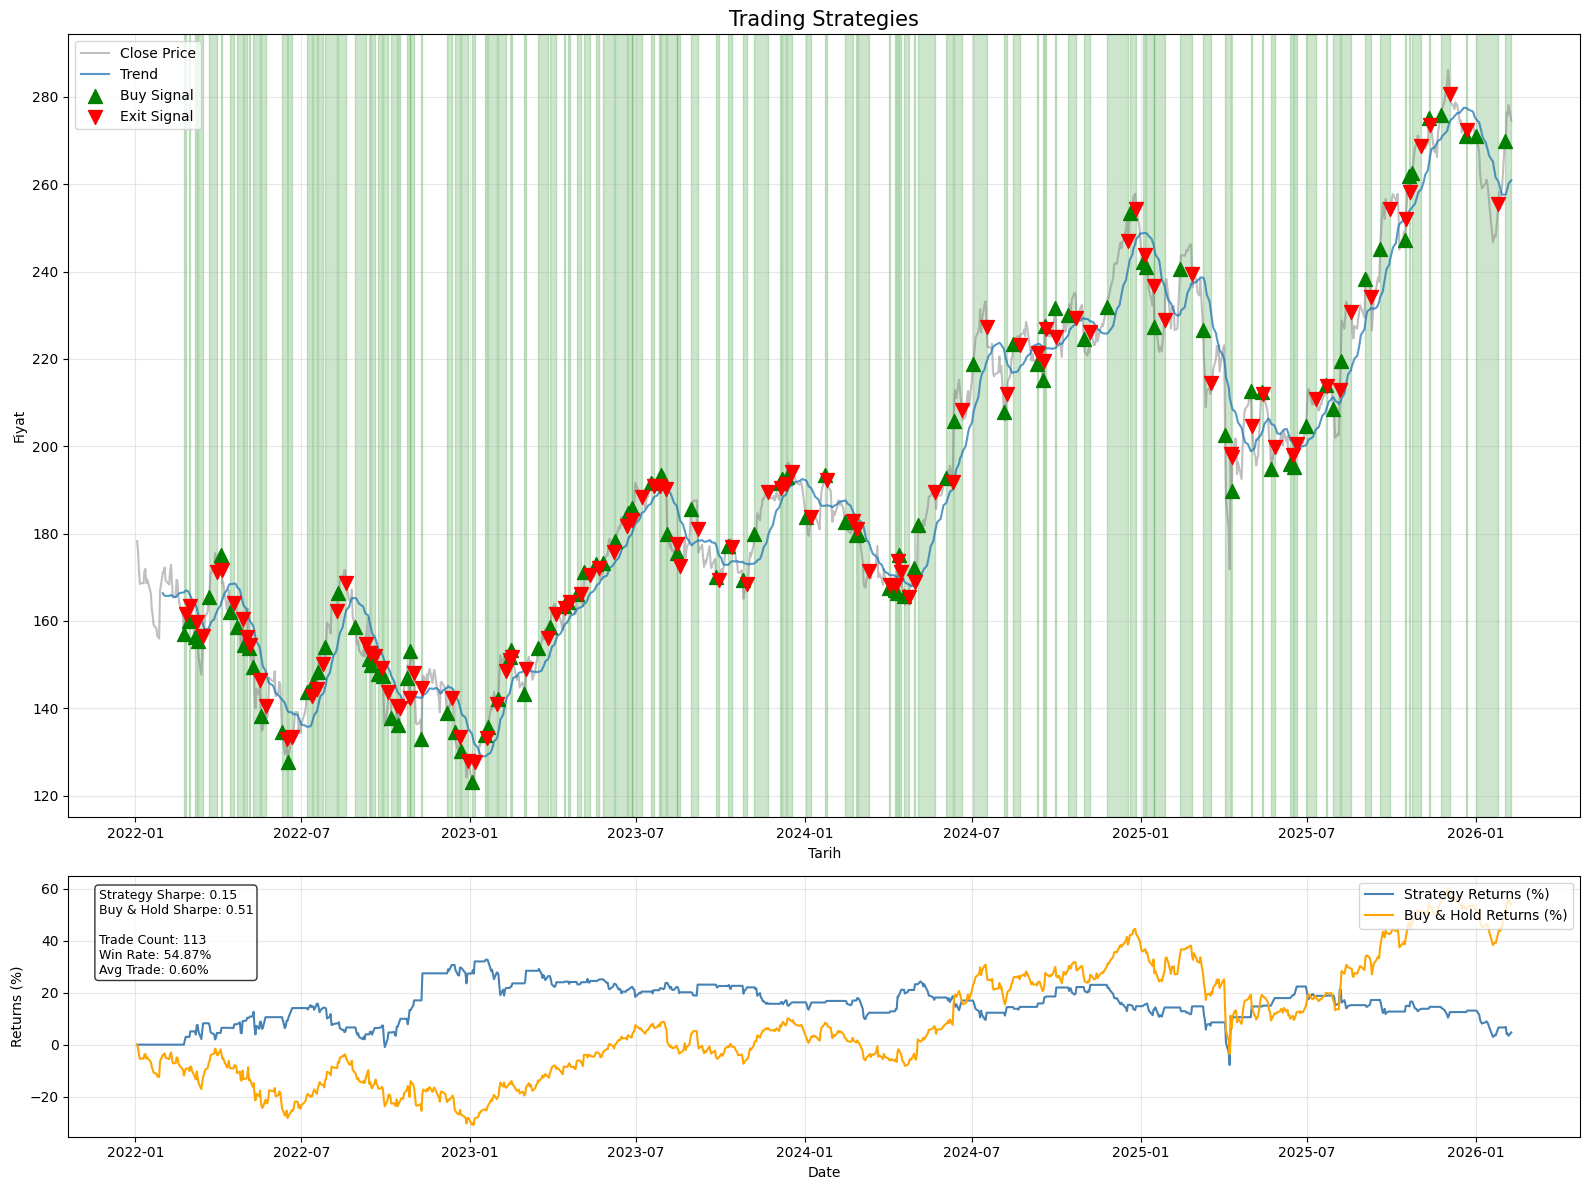

In [116]:
backtest(data_mr, ['Trend'])

## Statistical Arbitrage 

In [117]:
from statsmodels.tsa.stattools import coint

In [118]:
# Apple Futures data using yfinance
ticker_2 = 'NVDA'
data_2 = yf.download(ticker_2, start="2022-01-01")

# Check the data
display(data_2.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2022-01-03,30.062767,30.651627,29.727416,29.757359,391547000
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000
2022-01-05,27.550629,29.359125,27.479767,28.893027,498064000
2022-01-06,28.123518,28.383016,27.012671,27.586558,454186000
2022-01-07,27.194323,28.367052,27.004689,28.086595,409939000


In [119]:
data_2.columns = ['Close','High','Low','Open','Volume']

In [120]:
# Perform cointegration test
score, p_value, _ = coint(data['Close'], data_2['Close'])

print(f'Cointegration test p-value: {p_value}')

# If p-value is low (<0.05), the pairs are cointegrated
if p_value < 0.05:
    print("The pairs are cointegrated.")
else:
    print("The pairs are not cointegrated.")

Cointegration test p-value: 0.022283647071972737
The pairs are cointegrated.


In [121]:
new_data = pd.concat(
    [data['Close'], data_2['Close']],
    axis=1,
    keys= ['Close','NVDA_Close']
)

In [122]:
new_data.head()

,Close,NVDA_Close
Date,,
2022-01-03,178.270309,30.062767
2022-01-04,176.007782,29.233374
2022-01-05,171.325974,27.550629
2022-01-06,168.465988,28.123518
2022-01-07,168.632523,27.194323


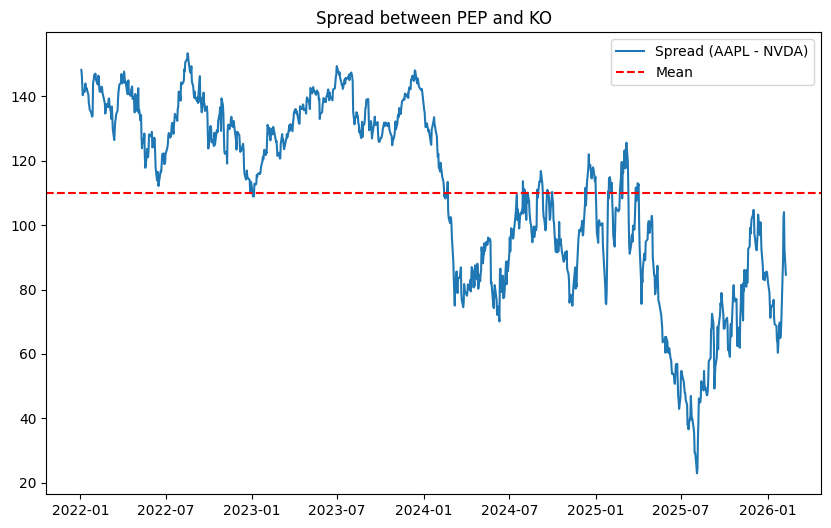

In [135]:
# Calculate the spread between the two stocks
new_data['Spread'] = new_data['Close'] - new_data['NVDA_Close']

# Plot the spread
plt.figure(figsize=(10, 6))
plt.plot(new_data.index, new_data['Spread'], label='Spread (AAPL - NVDA)')
plt.axhline(new_data['Spread'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.title('Spread between PEP and KO')
plt.show()

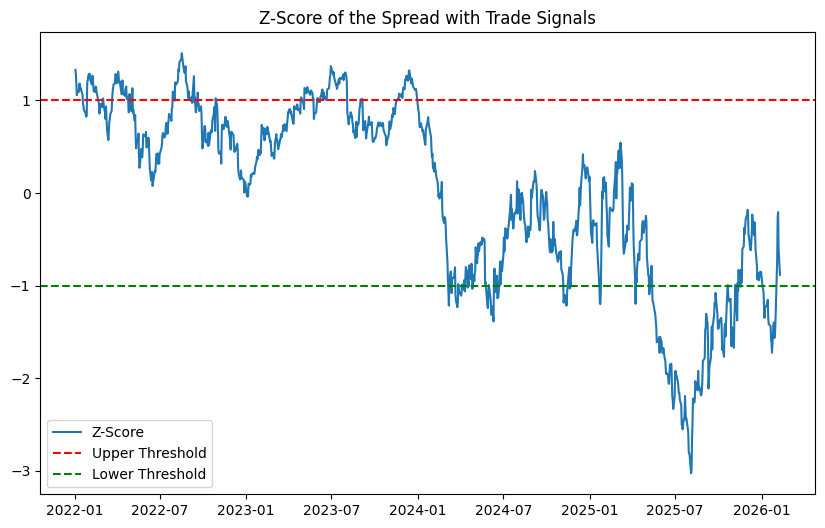

In [136]:
# Define z-score to normalize the spread
new_data['Z-Score'] = (new_data['Spread'] - new_data['Spread'].mean()) / new_data['Spread'].std()

# Set thresholds for entering and exiting trades
upper_threshold = 1
lower_threshold = -1

# Initialize signals
new_data['Position'] = 0

# Generate signals for long and short Signals
new_data['Position'] = np.where(new_data['Z-Score'] > upper_threshold, -1, new_data['Position'])  # Short the spread
new_data['Position'] = np.where(new_data['Z-Score'] < lower_threshold, 1, new_data['Position'])   # Long the spread
new_data['Position'] = np.where((new_data['Z-Score'] < 1) & (new_data['Z-Score'] > -1), 0, new_data['Position'])  # Exit
new_data['Signal'] = 0
# Plot z-score and Signals
plt.figure(figsize=(10, 6))
plt.plot(new_data.index, new_data['Z-Score'], label='Z-Score')
plt.axhline(upper_threshold, color='red', linestyle='--', label='Upper Threshold')
plt.axhline(lower_threshold, color='green', linestyle='--', label='Lower Threshold')
plt.legend()
plt.title('Z-Score of the Spread with Trade Signals')
plt.show()

In [137]:
new_data = set_position(new_data)

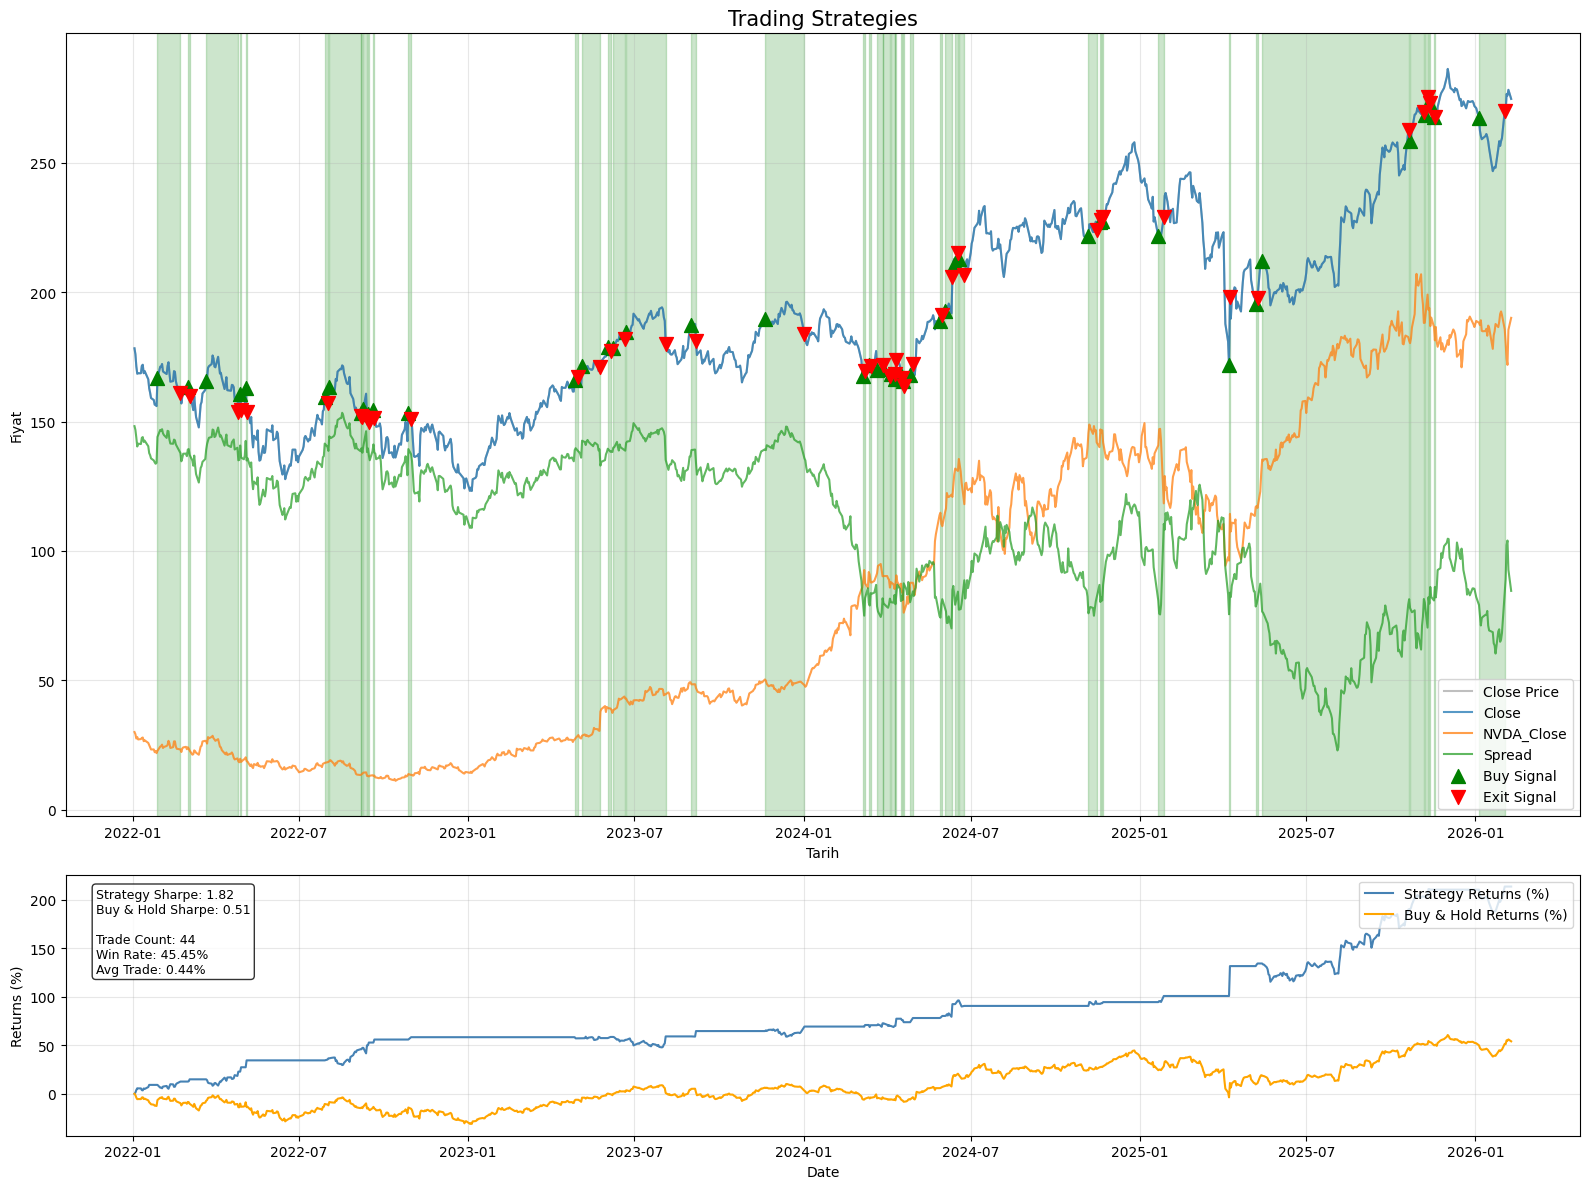

In [138]:
backtest(new_data, ['Close','NVDA_Close','Spread'])

## MACD 

In [127]:
data_macd = data.copy()

In [128]:
MACD_Line=ta.EMA(data_macd['Close'],12)-ta.EMA(data_macd['Close'],26)
Signal_Line=ta.EMA(MACD_Line,9)
diff=MACD_Line-Signal_Line
data_macd['MACD_Line']=MACD_Line
data_macd['Signal_Line']=Signal_Line
data_macd['Difference']=diff

In [129]:
data_macd.head()

,Close,High,Low,Open,Volume,MACD_Line,Signal_Line,Difference
Date,,,,,,,,
2022-01-03,178.270309,179.122444,174.058672,174.176201,104487900,NaN,NaN,NaN
2022-01-04,176.007782,179.181217,175.439697,178.877588,99310400,NaN,NaN,NaN
2022-01-05,171.325974,176.468103,171.051728,175.919612,94537600,NaN,NaN,NaN
2022-01-06,168.465988,171.698187,168.113384,169.151603,96904000,NaN,NaN,NaN
2022-01-07,168.632523,170.562047,167.515946,169.337730,86709100,NaN,NaN,NaN


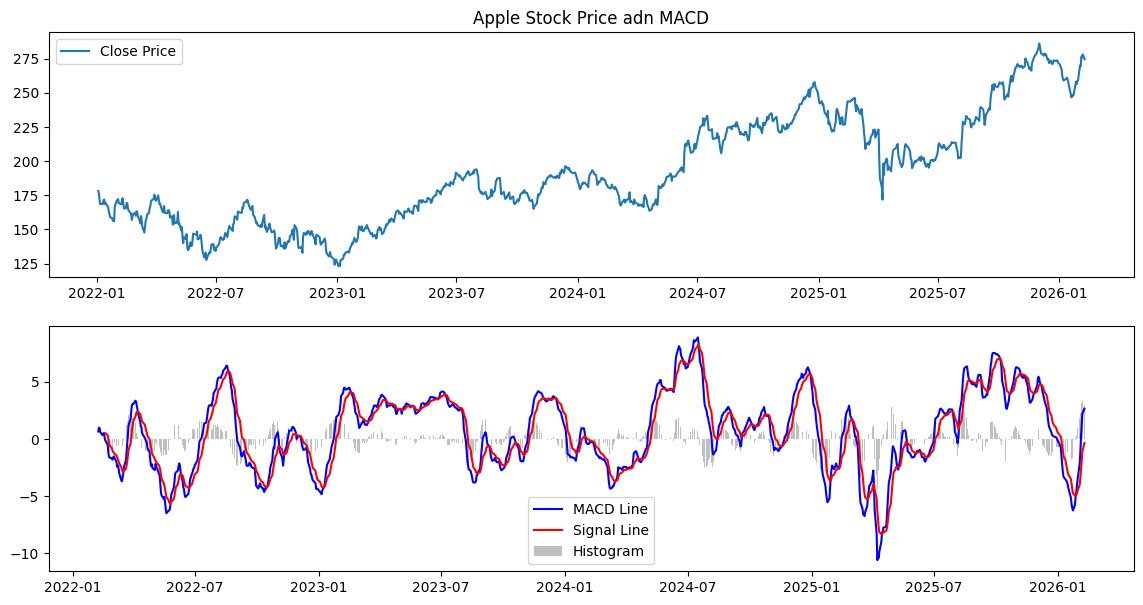

In [130]:
plt.figure(figsize=(14,7))

#Plotting Close Price
plt.subplot(2,1,1)
plt.plot(data_macd['Close'],label='Close Price')
plt.title('Apple Stock Price adn MACD')
plt.legend()

#Plottinf MACD
plt.subplot(2,1,2)
plt.plot(data_macd['MACD_Line'],label='MACD Line',color='blue')
plt.plot(data_macd['Signal_Line'], label='Signal Line', color='red')
plt.bar(data_macd.index, data_macd['Difference'],label='Histogram',color='grey',alpha=0.5)
plt.legend()

plt.show()

In [131]:
# Position: 1 (long), -1 (short), 0 (nötr)
data_macd['Position'] = 0

# MACD line > Signal line = Bullish (Long)
data_macd['Position'] = np.where(
    data_macd['MACD_Line'] > data_macd['Signal_Line'], 1, data_macd['Position']
)

# MACD line < Signal line = Bearish (Short)
data_macd['Position'] = np.where(
    data_macd['MACD_Line'] < data_macd['Signal_Line'], -1, data_macd['Position']
)

# Histogram threshold ile filtre (opsiyonel)
hist_threshold = 0.5
data_macd['Position'] = np.where(
    abs(data_macd['Difference']) < hist_threshold, 0, data_macd['Position']
)

In [132]:
data_macd['Signal'] = 0

In [133]:
data_macd = set_position(data_macd)

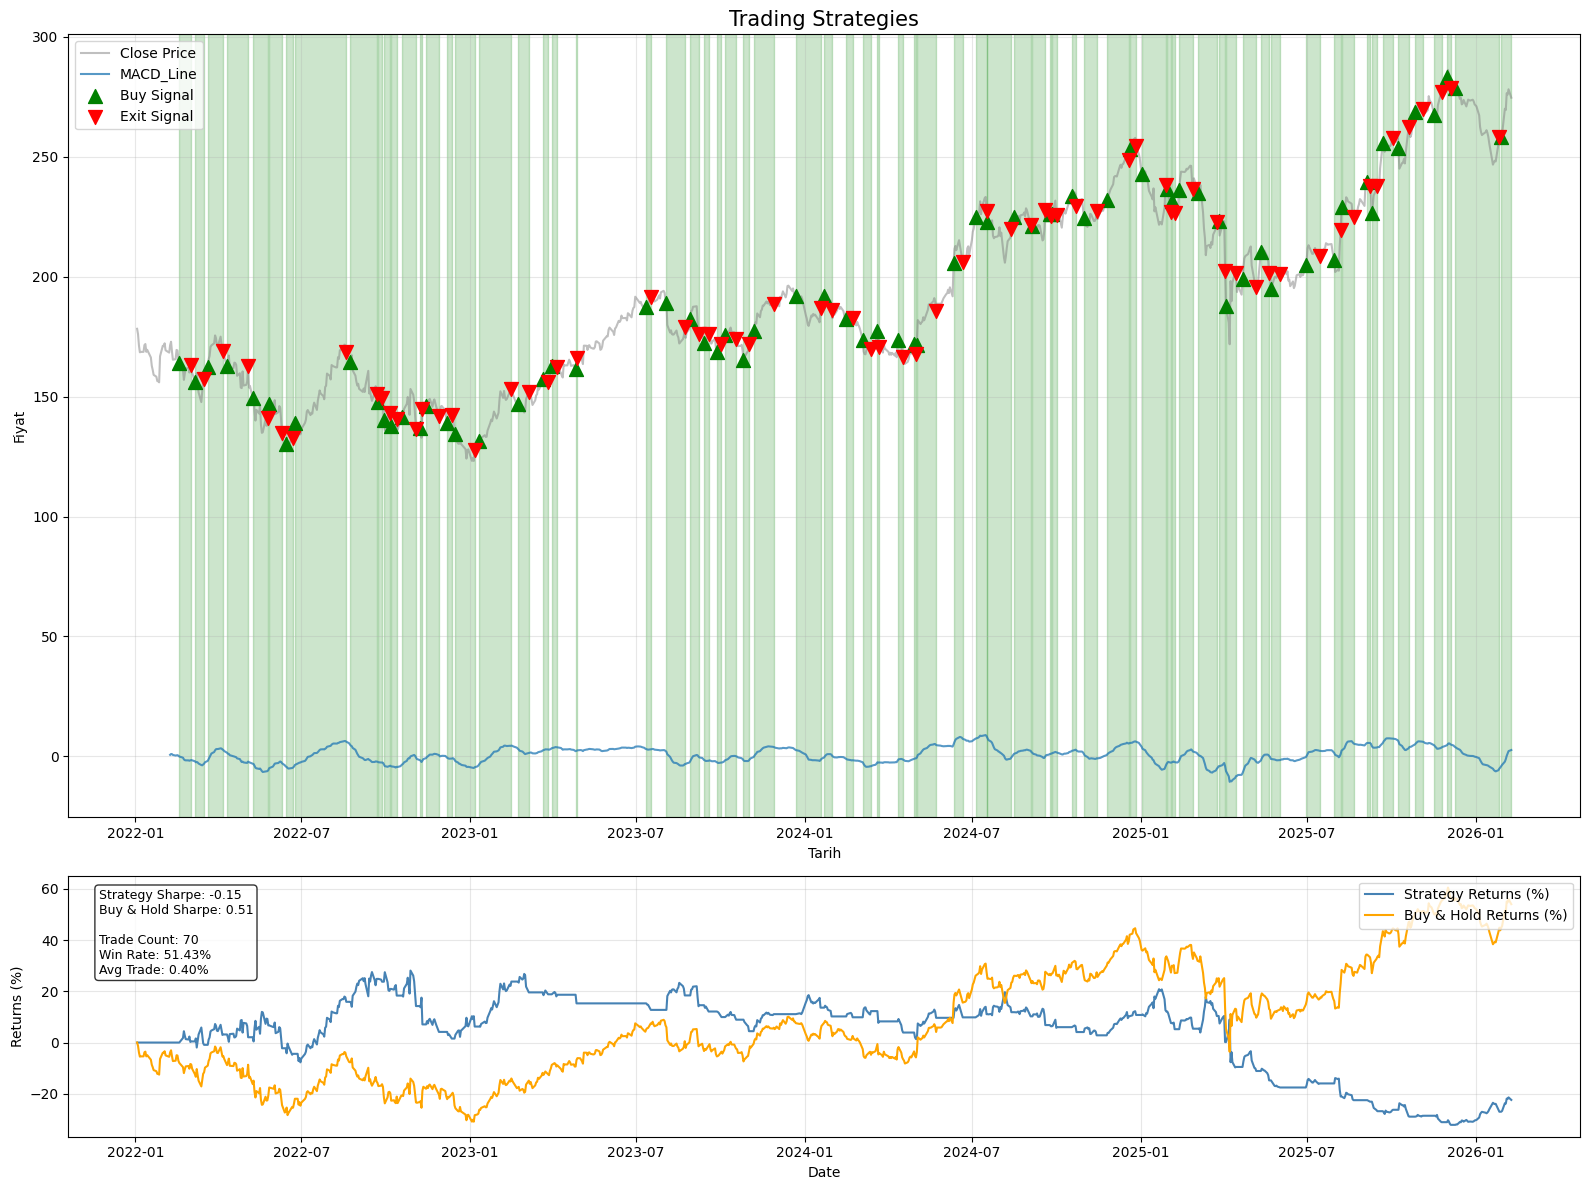

In [134]:
backtest(data_macd, trends=['MACD_Line'])